# 10-Task Fine-Tuning

In the previous lessons, we built Foundation Models. Whether it is an Encoder (BERT) predicting masked words or a Decoder (GPT) predicting the next word, these models were trained using **Self-Supervised Learning**. They read the entire internet to learn the fundamental physics of human language.

However, a raw Foundation Model is not a product. If you ask a raw base model, *"Is this movie review positive or negative?"*, it might just reply with another question, *"Is this restaurant review positive or negative?"* because it is merely continuing the pattern of the text.

To build an Enterprise AI product (like a Spam Detector, a Named Entity Recognizer, or a Summarizer), we must physically alter the architecture and mathematically force the model to follow human commands. This is called **Supervised Fine-Tuning (SFT)**.

Let's set up our PyTorch environment to perform architectural surgery on a Foundation Model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch & Hugging Face Transfer Learning Environment Ready.")

✅ PyTorch & Hugging Face Transfer Learning Environment Ready.


# 1. The Mathematics of Transfer Learning

Training a language model from absolute scratch costs millions of dollars and requires massive GPU clusters computing for months. **Transfer Learning** is the engineering shortcut that powers the modern AI industry.

Instead of starting from random noise, we download a Foundation Model that already possesses deep semantic understanding. We then perform **Architectural Surgery**:

1. **Decapitation**: We mathematically slice off the final Pre-Training Head (the `nn.Linear` layer that maps the 768-dimensional hidden state to the 50,257-word vocabulary).
2. **The Graft**: We bolt a brand-new, randomly initialized **Task Head** onto the final layer of the network.
3. **The Fine-Tuning**: We run Backpropagation using a small, high-quality, human-labeled dataset.

Because the body of the model already knows how to read English, it only takes a few hundred examples for the network to mathematically map its deep contextual vectors into the new random Task Head.

# 2. Architecting the Classification Head

Let's say we want to build a Sentiment Classifier (Positive vs. Negative).
If we use a BERT-style Encoder, you will recall from Lesson 07 that the absolute first token of every sequence is the `[CLS]` token. This token aggregates the semantic meaning of the entire sentence into a single vector.

Let $h_{CLS} \in \mathbb{R}^{d}$ be the contextualized embedding of the `[CLS]` token, where $d$ is the hidden dimension (e.g., $768$).
We initialize a new weight matrix $W_{task} \in \mathbb{R}^{d \times K}$, where $K$ is the number of classes (e.g., $2$ for Binary Sentiment).

The mathematics of the Task Head is a simple linear projection followed by a Softmax:


$$\hat{y} = \text{softmax}(h_{CLS} W_{task} + b_{task})$$

We then use **Cross-Entropy Loss** to calculate the distance between the predicted probability distribution and the true human label ($y$):


$$\mathcal{L} = -\sum_{c=1}^{K} y_c \log(\hat{y}_c)$$

During training, the massive gradients rapidly fix the random weights in $W_{task}$, while gently "fine-tuning" the 100 million parameters in the pre-trained body to perfectly align with the new objective.

# 3. Executing Architectural Surgery in PyTorch

Hugging Face provides classes like `AutoModelForSequenceClassification` that hide this surgery behind an API. As engineers, we must understand the raw physics. We will load a headless base model, manually code the Task Head, and observe the exact tensor dimensionality shifts.

In [2]:
# 1. Load the "Headless" Base Model (DistilBERT)
print("--- 📥 Initializing Headless Foundation Model ---")
# AutoModel loads ONLY the Transformer backbone, skipping the Language Modeling head
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
base_model = AutoModel.from_pretrained("distilbert-base-uncased")

HIDDEN_DIM = base_model.config.dim  # 768 for DistilBERT
NUM_CLASSES = 2                     # 0: Negative, 1: Positive

# 2. Architecting the Custom Task Head
class CustomSentimentClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        
        # THE GRAFT: A brand new, randomly initialized Linear Layer
        # It takes the 768-dimensional context and crushes it into exactly 2 logits
        self.classifier_head = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, input_ids, attention_mask):
        # 1. Extract the Deep Semantics from the Foundation Model
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # 2. Extract the [CLS] Token
        # In DistilBERT, the [CLS] token is strictly at sequence index 0
        # Shape: [Batch_Size, Sequence_Length, Hidden_Dim] -> [Batch, 768]
        cls_token_state = outputs.last_hidden_state[:, 0, :]
        
        # 3. Pass through the Task Head
        dropped_out = self.dropout(cls_token_state)
        logits = self.classifier_head(dropped_out)
        
        return logits

print("--- ⚙️ Grafting Task Head to Foundation Backbone ---")
task_model = CustomSentimentClassifier(base_model, HIDDEN_DIM, NUM_CLASSES)
print(f"Surgery Complete. The network now outputs {NUM_CLASSES} classes instead of vocabulary probabilities.")

--- 📥 Initializing Headless Foundation Model ---


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2026-06-16 14:29:55.090264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

--- ⚙️ Grafting Task Head to Foundation Backbone ---
Surgery Complete. The network now outputs 2 classes instead of vocabulary probabilities.


# 4. Simulating the SFT Training Loop

To mathematically prove how fast Transfer Learning works, we will construct a micro-dataset of two sentences (one Positive, one Negative). Because the Task Head is initialized with random weights, its first prediction will be essentially a 50/50 blind guess.

We will run exactly 10 epochs of Backpropagation and physically plot the model learning to map its deep knowledge into the new head.


--- 🚀 Executing Supervised Fine-Tuning (SFT) ---
Epoch 01 | Loss: 0.6457 | Pos Doc Conf: 0.47 | Neg Doc Conf: 0.59
Epoch 02 | Loss: 0.6447 | Pos Doc Conf: 0.40 | Neg Doc Conf: 0.68
Epoch 03 | Loss: 0.5540 | Pos Doc Conf: 0.48 | Neg Doc Conf: 0.69
Epoch 04 | Loss: 0.5852 | Pos Doc Conf: 0.46 | Neg Doc Conf: 0.67
Epoch 05 | Loss: 0.4126 | Pos Doc Conf: 0.59 | Neg Doc Conf: 0.74
Epoch 06 | Loss: 0.3805 | Pos Doc Conf: 0.60 | Neg Doc Conf: 0.78
Epoch 07 | Loss: 0.2912 | Pos Doc Conf: 0.72 | Neg Doc Conf: 0.77
Epoch 08 | Loss: 0.2036 | Pos Doc Conf: 0.74 | Neg Doc Conf: 0.89
Epoch 09 | Loss: 0.1687 | Pos Doc Conf: 0.83 | Neg Doc Conf: 0.86
Epoch 10 | Loss: 0.0987 | Pos Doc Conf: 0.87 | Neg Doc Conf: 0.94


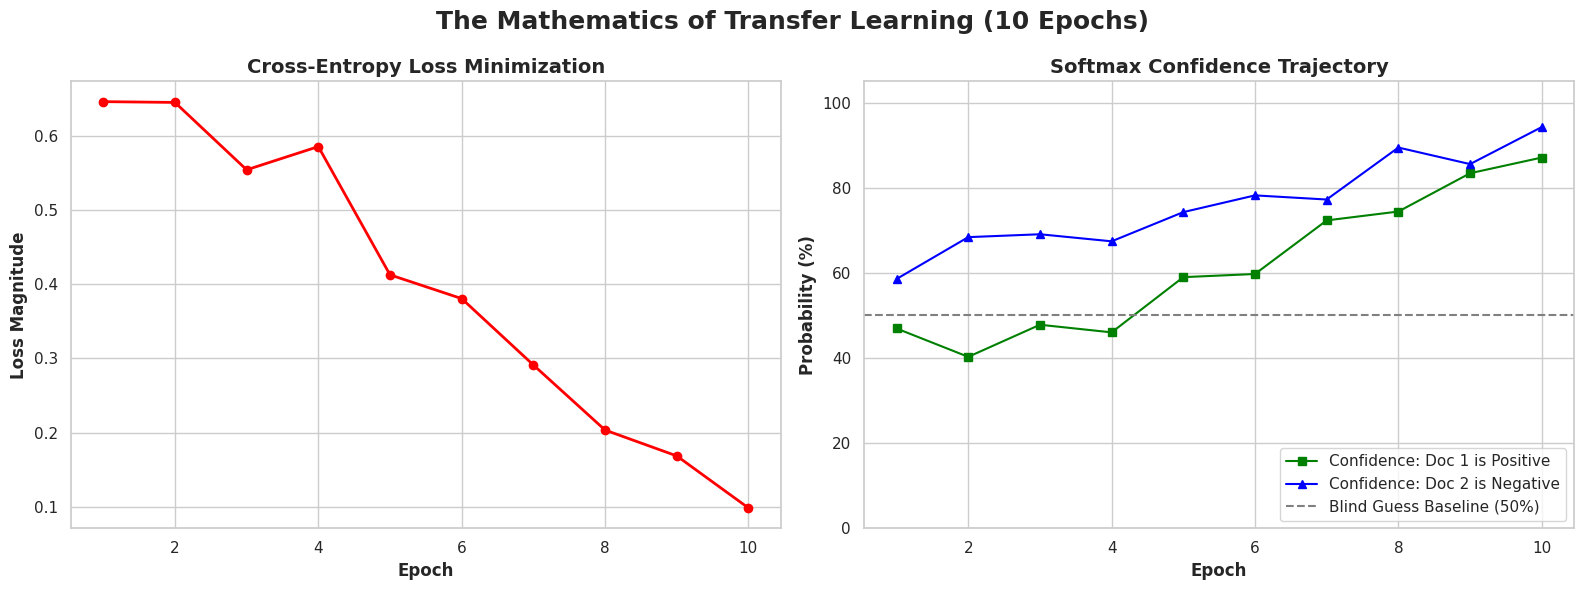


--- 💡 Engineering Insight ---
Look at Epoch 1 in the second graph. Because our new Task Head was initialized with random numbers, the model was basically guessing (hovering near 50%). But notice what happens by Epoch 10! The loss plummets to near zero, and the model becomes highly confident.
How did it learn so fast from just two sentences? Because it didn't have to learn English! The pre-trained Base Model already mathematically mapped 'love' and 'terribly' to vastly different coordinates in the 768-dimensional space. All the network had to do was rotate the small 768x2 random matrix (the Task Head) until those distinct coordinates aligned with the output logits for 1 and 0.


In [3]:
# 1. Define the Micro-Dataset
texts = [
    "I absolutely love this new API, it is incredibly fast and intuitive!",  # True Label: 1 (Positive)
    "The documentation is terribly confusing and the system constantly crashes." # True Label: 0 (Negative)
]
labels = torch.tensor([1, 0], dtype=torch.long)

# Tokenize and format the batch
encoded_batch = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
input_ids = encoded_batch['input_ids']
attention_mask = encoded_batch['attention_mask']

# 2. Initialize the Mathematical Optimizer
# We use a very small learning rate (2e-5) to protect the pre-trained weights from catastrophic forgetting!
optimizer = optim.AdamW(task_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# 3. Execute the Micro-Training Loop
EPOCHS = 10
loss_history = []
prob_history_pos_doc = [] # Tracking the model's confidence on the Positive document
prob_history_neg_doc = [] # Tracking the model's confidence on the Negative document

print("\n--- 🚀 Executing Supervised Fine-Tuning (SFT) ---")
task_model.train()

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Forward Pass
    logits = task_model(input_ids, attention_mask)
    
    # Calculate Cross-Entropy Loss
    loss = criterion(logits, labels)
    
    # Backpropagation!
    loss.backward()
    optimizer.step()
    
    # Track Metrics for Visualization
    loss_history.append(loss.item())
    
    # Calculate raw probabilities using Softmax
    probs = F.softmax(logits, dim=-1).detach()
    # Store confidence that Doc 1 is Positive (Index 1) and Doc 2 is Negative (Index 0)
    prob_history_pos_doc.append(probs[0, 1].item() * 100)
    prob_history_neg_doc.append(probs[1, 0].item() * 100)
    
    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Pos Doc Conf: {probs[0, 1]:.2f} | Neg Doc Conf: {probs[1, 0]:.2f}")

# 4. Visualizing the Transfer Learning Calculus
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("The Mathematics of Transfer Learning (10 Epochs)", fontsize=18, fontweight='bold')

# Plot A: The Loss Curve
axes[0].plot(range(1, EPOCHS+1), loss_history, color='red', marker='o', linewidth=2)
axes[0].set_title("Cross-Entropy Loss Minimization", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Epoch", fontweight='bold')
axes[0].set_ylabel("Loss Magnitude", fontweight='bold')
axes[0].grid(True)

# Plot B: The Probability Shift
axes[1].plot(range(1, EPOCHS+1), prob_history_pos_doc, color='green', marker='s', label="Confidence: Doc 1 is Positive")
axes[1].plot(range(1, EPOCHS+1), prob_history_neg_doc, color='blue', marker='^', label="Confidence: Doc 2 is Negative")
axes[1].axhline(y=50, color='gray', linestyle='--', label="Blind Guess Baseline (50%)")
axes[1].set_title("Softmax Confidence Trajectory", fontweight='bold', fontsize=14)
axes[1].set_xlabel("Epoch", fontweight='bold')
axes[1].set_ylabel("Probability (%)", fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at Epoch 1 in the second graph. Because our new Task Head was initialized with random numbers, the model was basically guessing (hovering near 50%). But notice what happens by Epoch 10! The loss plummets to near zero, and the model becomes highly confident.")
print("How did it learn so fast from just two sentences? Because it didn't have to learn English! The pre-trained Base Model already mathematically mapped 'love' and 'terribly' to vastly different coordinates in the 768-dimensional space. All the network had to do was rotate the small 768x2 random matrix (the Task Head) until those distinct coordinates aligned with the output logits for 1 and 0.")

## Real-World Use Case or Analogy:

Think of Task Fine-Tuning like **A Medical Residency**:

* **Pre-Training (Medical School)**: A student spends 4 years reading every medical textbook in existence. They learn anatomy, biochemistry, and physiology. This costs hundreds of thousands of dollars and takes years (Training a Base Model from scratch on Wikipedia). When they graduate, they have a massive, deep understanding of the human body, but they are generalists. You wouldn't hire them to perform open-heart surgery on day one.
* **Supervised Fine-Tuning (The Residency)**: The graduate goes into a 6-month highly specialized surgical residency. They are exposed to a few hundred exact examples of heart surgery (The SFT Labeled Dataset). Because they *already know* the anatomy of the heart, they don't have to re-learn biology. They just have to "fine-tune" their deep existing knowledge to execute the specific mechanical task of holding the scalpel (The Task Head). Within a few months, they are an expert surgeon.